# Ensemble Methods, Bias-Variance & Regularization
### Hack-o-Week | ArpitaBuilds

**Covers:**
- Ensemble methods: Bagging & Boosting, with focus on XGBoost and LightGBM
- Bias-variance tradeoff and its impact on model performance
- Overfitting & underfitting: causes, identification, prevention
- Regularization (L1/L2): how it controls overfitting and improves generalization

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin** dataset — same one from earlier
notebooks, so results are directly comparable, and it loads with zero downloading.

**Why this matters for your project — directly:** your stroke risk platform literally uses **XGBoost**
as its main model. This notebook is the "why does XGBoost work" notebook — bagging vs boosting,
bias-variance, and regularization are the exact concepts a reviewer or interviewer will ask about when
you say "I used XGBoost with SHAP."


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)
PINK, BLUE, GRAY, ORANGE = '#ff2d78', '#2d9dff', '#888888', '#f5a623'
print("Setup done ✅")

Setup done ✅


In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


---
## 1. Why Combine Models at All?

A single decision tree is easy to interpret but tends to be either too simple (shallow tree) or wildly
overfit (deep tree) — it has high **variance**: small changes in training data can produce a very
different tree.

**Ensemble methods** combine many "weak" or moderately good models into one stronger model. There are
two fundamentally different strategies:
- **Bagging** — train many models **independently and in parallel**, each on a random subset of data,
  then average their predictions. Reduces **variance**.
- **Boosting** — train models **sequentially**, where each new model specifically focuses on fixing
  the mistakes of the previous ones. Reduces **bias**.

---
## 2. Bagging (Bootstrap Aggregating)

Each model is trained on a random sample of the training data **drawn with replacement** (a
"bootstrap" sample — some rows repeat, some are left out entirely). All models train independently, in
parallel, and their predictions are combined by majority vote (classification) or averaging
(regression).

**Random Forest** is bagging applied to decision trees, with one extra trick: each tree also only
considers a random subset of *features* at each split, which decorrelates the trees further.

In [3]:
single_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree.fit(X_train, y_train)
print(f"Single deep tree      - train acc: {single_tree.score(X_train, y_train):.3f}  test acc: {single_tree.score(X_test, y_test):.3f}")

bagged_trees = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagged_trees.fit(X_train, y_train)
print(f"Bagging (100 trees)    - train acc: {bagged_trees.score(X_train, y_train):.3f}  test acc: {bagged_trees.score(X_test, y_test):.3f}")

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
print(f"Random Forest (100 trees) - train acc: {random_forest.score(X_train, y_train):.3f}  test acc: {random_forest.score(X_test, y_test):.3f}")

Single deep tree      - train acc: 1.000  test acc: 0.912


Bagging (100 trees)    - train acc: 1.000  test acc: 0.939
Random Forest (100 trees) - train acc: 1.000  test acc: 0.956


**Key takeaway:** the single deep tree usually gets near-perfect train accuracy but noticeably
worse test accuracy — classic overfitting. Bagging and Random Forest close that gap: train and test
accuracy stay much closer together, because averaging many trees cancels out each individual tree's
overfit quirks.

---
## 3. Boosting

Instead of training independently, boosting builds models **one at a time**, and each new model is
trained specifically to correct the errors of everything built so far. The final prediction is a
weighted combination of all the models.

- **AdaBoost:** reweights *data points* — misclassified points get more weight so the next model pays
  more attention to them
- **Gradient Boosting:** each new model fits the **residual errors** (the gradient of the loss, from
  your calculus notebook) of the combined models so far
- **XGBoost** ("eXtreme Gradient Boosting"): gradient boosting with extra engineering — regularization
  built in, uses both first and second-order gradients (Hessian), and handles missing values natively
- **LightGBM:** also gradient boosting, but grows trees **leaf-wise** instead of level-wise, and bins
  continuous features into discrete buckets — usually faster on large datasets, at a slightly higher
  overfitting risk on small ones

In [4]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
print(f"AdaBoost         - train acc: {ada.score(X_train, y_train):.3f}  test acc: {ada.score(X_test, y_test):.3f}")

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print(f"Gradient Boosting - train acc: {gb.score(X_train, y_train):.3f}  test acc: {gb.score(X_test, y_test):.3f}")

xgb_model = xgb.XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
print(f"XGBoost          - train acc: {xgb_model.score(X_train, y_train):.3f}  test acc: {xgb_model.score(X_test, y_test):.3f}")

lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
print(f"LightGBM         - train acc: {lgb_model.score(X_train, y_train):.3f}  test acc: {lgb_model.score(X_test, y_test):.3f}")

AdaBoost         - train acc: 1.000  test acc: 0.956


Gradient Boosting - train acc: 1.000  test acc: 0.956
XGBoost          - train acc: 1.000  test acc: 0.956
LightGBM         - train acc: 1.000  test acc: 0.965


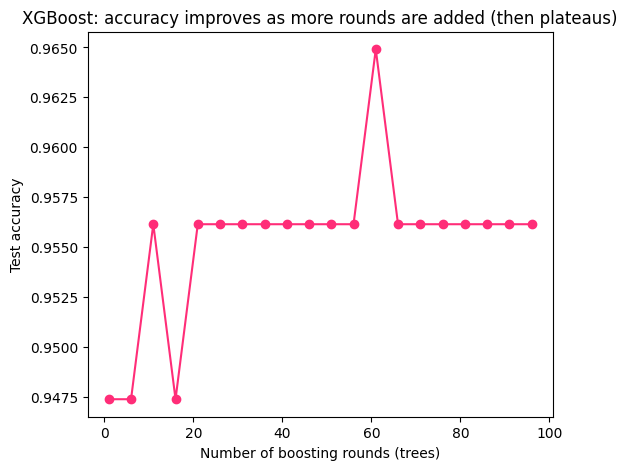

In [5]:
# Boosting learns progressively -- watch test accuracy improve as more trees (rounds) are added
n_rounds = range(1, 101, 5)
test_scores = []
for n in n_rounds:
    m = xgb.XGBClassifier(n_estimators=n, eval_metric='logloss', random_state=42)
    m.fit(X_train, y_train)
    test_scores.append(m.score(X_test, y_test))

plt.plot(list(n_rounds), test_scores, 'o-', color=PINK)
plt.xlabel('Number of boosting rounds (trees)'); plt.ylabel('Test accuracy')
plt.title('XGBoost: accuracy improves as more rounds are added (then plateaus)')
plt.show()

**Key takeaway:** boosting keeps improving as you add more rounds, but only up to a point — past
that, more rounds start overfitting to training noise (this is exactly why `early_stopping_rounds` and
`n_estimators` are hyperparameters you tune, not just crank to the maximum).

**Direct connection to your project:** your stroke platform already uses XGBoost — this is the
mechanism you're actually relying on. If you want to explain "why XGBoost over Random Forest" in your
report: XGBoost's sequential error-correction (boosting) typically achieves better predictive
performance on structured/tabular data than bagging-based Random Forest, at the cost of being
slightly more prone to overfitting if not regularized — which is exactly the next section.

---
## 4. Bias-Variance Tradeoff

Every model's prediction error can be split into three parts:
`Total Error = Bias² + Variance + Irreducible Noise`

- **Bias:** error from wrong assumptions (e.g. fitting a straight line to curved data) — a high-bias
  model is too simple and **underfits**
- **Variance:** error from being too sensitive to the specific training data (e.g. an overly wiggly
  curve chasing noise) — a high-variance model **overfits**
- There's a fundamental tradeoff: making a model more flexible reduces bias but increases variance,
  and vice versa

We saw this exact tradeoff already in the polynomial regression notebook (degree 1 = high bias, degree
15 = high variance) — let's make it explicit here with a bias-variance decomposition experiment.

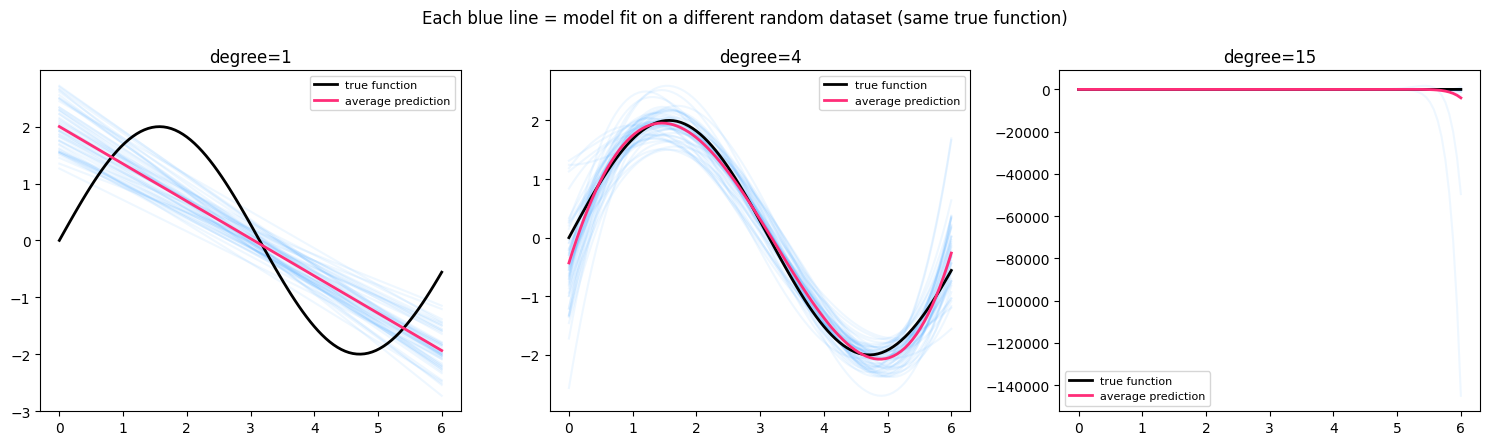

In [6]:
# Simulate many different noisy training sets from the same true function,
# fit a model to each, and see how much predictions vary vs how far off they are on average
def true_function(x):
    return np.sin(x) * 2

x_range = np.linspace(0, 6, 100)
n_datasets = 50

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, degree in zip(axes, [1, 4, 15]):
    predictions = []
    for i in range(n_datasets):
        x_train_sim = np.random.uniform(0, 6, 25)
        y_train_sim = true_function(x_train_sim) + np.random.normal(0, 0.5, 25)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(x_train_sim.reshape(-1,1), y_train_sim)
        pred = model.predict(x_range.reshape(-1,1))
        predictions.append(pred)
        ax.plot(x_range, pred, color=BLUE, alpha=0.08)

    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    ax.plot(x_range, true_function(x_range), color='black', linewidth=2, label='true function')
    ax.plot(x_range, mean_pred, color=PINK, linewidth=2, label='average prediction')
    ax.set_title(f"degree={degree}")
    ax.legend(fontsize=8)

plt.suptitle("Each blue line = model fit on a different random dataset (same true function)")
plt.tight_layout()
plt.show()

**How to read this:** at **degree=1**, all 50 blue lines nearly overlap (low variance) but they
all miss the true curve's shape (high bias — underfitting). At **degree=15**, the blue lines are all
over the place — wildly different depending on which random dataset they saw (high variance —
overfitting), even though on average they roughly get the shape right. **degree=4** is the sweet spot:
reasonably tight lines that also track the true curve.

---
## 5. Overfitting & Underfitting — Causes, Identification, Prevention

| | Underfitting (high bias) | Overfitting (high variance) |
|---|---|---|
| **Cause** | Model too simple, too few features, too much regularization | Model too complex, too little data, too little regularization |
| **Identify** | Low accuracy on *both* train and test | High train accuracy, much lower test accuracy |
| **Fix** | Add features, increase model complexity, reduce regularization, train longer | Get more data, reduce model complexity, add regularization, early stopping, cross-validation |

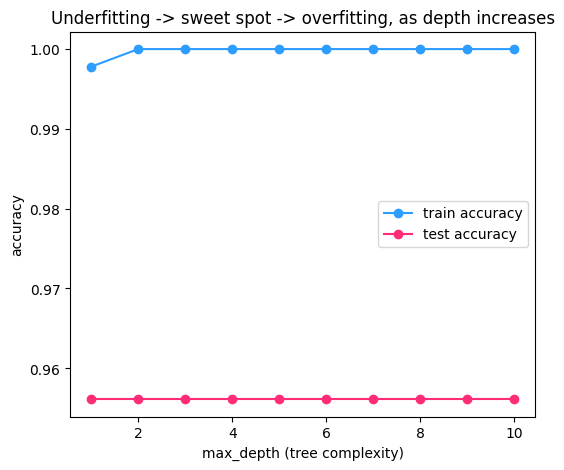

In [7]:
# Direct diagnostic: compare train vs test performance across increasing XGBoost tree depth
depths = range(1, 11)
train_scores, test_scores = [], []

for d in depths:
    m = xgb.XGBClassifier(max_depth=d, n_estimators=100, eval_metric='logloss', random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

plt.plot(list(depths), train_scores, 'o-', color=BLUE, label='train accuracy')
plt.plot(list(depths), test_scores, 'o-', color=PINK, label='test accuracy')
plt.xlabel('max_depth (tree complexity)'); plt.ylabel('accuracy')
plt.title('Underfitting -> sweet spot -> overfitting, as depth increases')
plt.legend()
plt.show()

**Reading this plot:** at very low depth, both lines are low (underfitting). As depth grows,
both improve, then train accuracy keeps climbing toward 1.0 while test accuracy plateaus or drops — the
widening gap between the two lines **is** overfitting. The best `max_depth` is where test accuracy
peaks, not where train accuracy is highest.

---
## 6. Regularization (L1/L2)

Regularization fights overfitting by adding a penalty for complexity directly into the loss function:

`loss = prediction_error + alpha * penalty(weights)`

- **L2 (Ridge-style):** penalty = sum of squared weights — shrinks all weights smoothly toward 0
- **L1 (Lasso-style):** penalty = sum of absolute weights — can shrink weights to **exactly** 0,
  effectively removing unhelpful features

XGBoost has both built in directly: `reg_lambda` (L2) and `reg_alpha` (L1), applied to the leaf weights
of every tree — this is a core part of why XGBoost tends to generalize better than plain gradient
boosting.

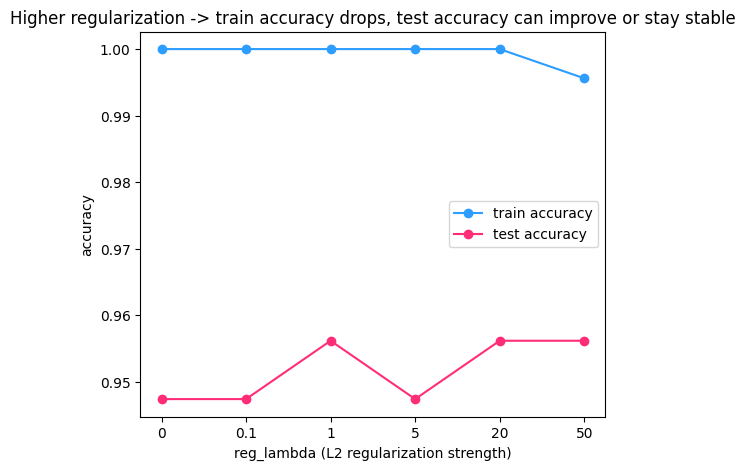

Test accuracy per reg_lambda: {0: np.float64(0.947), 0.1: np.float64(0.947), 1: np.float64(0.956), 5: np.float64(0.947), 20: np.float64(0.956), 50: np.float64(0.956)}


In [8]:
# Effect of XGBoost's regularization strength on train/test gap
reg_values = [0, 0.1, 1, 5, 20, 50]
train_scores, test_scores = [], []

for reg in reg_values:
    m = xgb.XGBClassifier(max_depth=6, n_estimators=100, reg_lambda=reg, eval_metric='logloss', random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

x_pos = range(len(reg_values))
plt.plot(x_pos, train_scores, 'o-', color=BLUE, label='train accuracy')
plt.plot(x_pos, test_scores, 'o-', color=PINK, label='test accuracy')
plt.xticks(x_pos, reg_values)
plt.xlabel('reg_lambda (L2 regularization strength)'); plt.ylabel('accuracy')
plt.title('Higher regularization -> train accuracy drops, test accuracy can improve or stay stable')
plt.legend()
plt.show()

print("Test accuracy per reg_lambda:", dict(zip(reg_values, np.round(test_scores, 3))))

**Key takeaway:** with too little regularization, the model memorizes training data (train
accuracy near-perfect, test accuracy lower). Cranking regularization too high makes the model
underfit both sets. The right `reg_lambda`/`reg_alpha` closes the train-test gap without hurting test
performance — this is a real hyperparameter you'll want to tune (via cross-validation) on your stroke
model, not just leave at the default.

---
## Recap Cheat Sheet

| Concept | One-line intuition | Where it fits your project |
|---|---|---|
| Bagging | Train many models in parallel on random samples, average results | Reduces variance; Random Forest is bagging + decision trees |
| Boosting | Train models sequentially, each fixing the last one's mistakes | Reduces bias; XGBoost/LightGBM are boosting |
| XGBoost | Gradient boosting + built-in L1/L2 regularization + 2nd-order gradients | Your project's main model |
| LightGBM | Gradient boosting, leaf-wise growth, faster on large data | An alternative worth comparing against XGBoost |
| Bias | Error from a model being too simple | Underfitting — model misses real patterns |
| Variance | Error from a model being too sensitive to training data | Overfitting — model memorizes noise |
| Regularization (L1/L2) | Penalize large/complex weights in the loss function | `reg_alpha`/`reg_lambda` in XGBoost — tune, don't leave at default |

## Self-check (try before moving on)
1. Why does bagging reduce variance but not really fix high bias?
2. Why does boosting reduce bias, and why can it be more prone to overfitting than bagging if left unchecked?
3. In the depth-vs-accuracy plot, how do you know if a `max_depth` value is underfitting vs overfitting?
4. What's the practical difference between what L1 and L2 regularization each do to model weights?
5. Why might LightGBM overfit more easily than XGBoost on a small dataset, based on how it grows trees?

## Next step
Run the `max_depth` and `reg_lambda` diagnostic cells from this notebook directly on your stroke
dataset's XGBoost model — the resulting "sweet spot" plots are a strong addition to your project
report, showing you tuned hyperparameters deliberately rather than using defaults.
